In [320]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import statsmodels.formula.api as smf 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/united-kingdom-real-estate-and-population-data/data_2014.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2005.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2006.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2013.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2011.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2001.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2015.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_month_clean.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2017.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2016.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2012.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2007.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data_2004.csv
/kaggle/input/unit

In [321]:
from IPython.core.display import HTML 
def short_summary(est): 
    return HTML(est.summary().tables[1].as_html()) 

# Data Cleaning

In [359]:
data = pd.read_csv('/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv')
print(data.shape)
data.dtypes

(7853837, 13)


Unnamed: 0            int64
Code                 object
Name                 object
Geography            object
Area (sq km)        float64
Price                 int64
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object
pp_sq_m             float64
est_pop             float64
dtype: object

In [360]:
filter = data.Name == 'NEWCASTLE UPON TYNE'
data_new = data.loc[filter,: ].copy(deep = True)
data_new.shape

(102808, 13)

In [324]:
data_new.columns

Index(['Unnamed: 0', 'Code', 'Name', 'Geography', 'Area (sq km)', 'Price',
       'Date of Transfer', 'Property Type', 'Old/New', 'Duration',
       'PPDCategory Type', 'pp_sq_m', 'est_pop'],
      dtype='object')

In [361]:
columns = ['Price','Property Type', 'Old/New', 'Duration', 'Date of Transfer']
data_new = data_new.loc[:, columns]
data_new.head()

,Price,Property Type,Old/New,Duration,Date of Transfer
132800,112000,S,Y,F,2001-11-16
132801,62500,F,N,L,2001-07-30
132802,72500,T,N,F,2001-06-15
132803,35000,F,N,L,2001-04-27
132804,113000,F,N,F,2001-10-31


In [362]:
data_new['date'] = pd.to_datetime(data_new['Date of Transfer'])
data_new['month'] = data_new['date'].dt.month
data_new['year'] = data_new['date'].dt.year
data_new


,Price,Property Type,Old/New,Duration,Date of Transfer,date,month,year
132800,112000,S,Y,F,2001-11-16,2001-11-16,11,2001
132801,62500,F,N,L,2001-07-30,2001-07-30,7,2001
132802,72500,T,N,F,2001-06-15,2001-06-15,6,2001
132803,35000,F,N,L,2001-04-27,2001-04-27,4,2001
132804,113000,F,N,F,2001-10-31,2001-10-31,10,2001
...,...,...,...,...,...,...,...,...
5299753,112995,F,Y,L,2017-02-27,2017-02-27,2,2017
5299754,284995,D,Y,L,2017-02-03,2017-02-03,2,2017
5299755,129995,T,Y,L,2017-02-10,2017-02-10,2,2017
5299756,208995,S,Y,L,2017-03-07,2017-03-07,3,2017


In [327]:
data_new['Old/New'] = data_new['Old/New'].astype('category')
data_new['old_new_codes'] = data_new['Old/New'].cat.codes
data_new['Property Type'] = data_new['Property Type'].astype('category')
data_new['property_types_codes'] = data_new['Property Type'].cat.codes
data_new['Duration'] = data_new['Old/New'].astype('category')
data_new['duration_code'] = data_new['Duration'].cat.codes
data_new['Price_log'] = np.log10(data_new['Price'])
data_new.head()


,Price,Property Type,Old/New,Duration,Date of Transfer,date,month,year,old_new_codes,property_types_codes,duration_code,Price_log
132800,112000,S,Y,Y,2001-11-16,2001-11-16,11,2001,1,3,1,5.049218
132801,62500,F,N,N,2001-07-30,2001-07-30,7,2001,0,1,0,4.795880
132802,72500,T,N,N,2001-06-15,2001-06-15,6,2001,0,4,0,4.860338
132803,35000,F,N,N,2001-04-27,2001-04-27,4,2001,0,1,0,4.544068
132804,113000,F,N,N,2001-10-31,2001-10-31,10,2001,0,1,0,5.053078


In [365]:
data_new.groupby(['Duration']).describe()['Price']


,count,mean,min,25%,50%,75%,max,std
Duration,,,,,,,,
F,64736.0,180881.737565,1.0,90000.0,135997.5,209837.5,74937156.0,503344.192151
L,38071.0,133640.137427,100.0,78000.0,119500.0,162068.0,31600000.0,312109.141559
U,1.0,96000.000000,96000.0,96000.0,96000.0,96000.0,96000.0,NaN


In [329]:
data_new = data_new.dropna()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


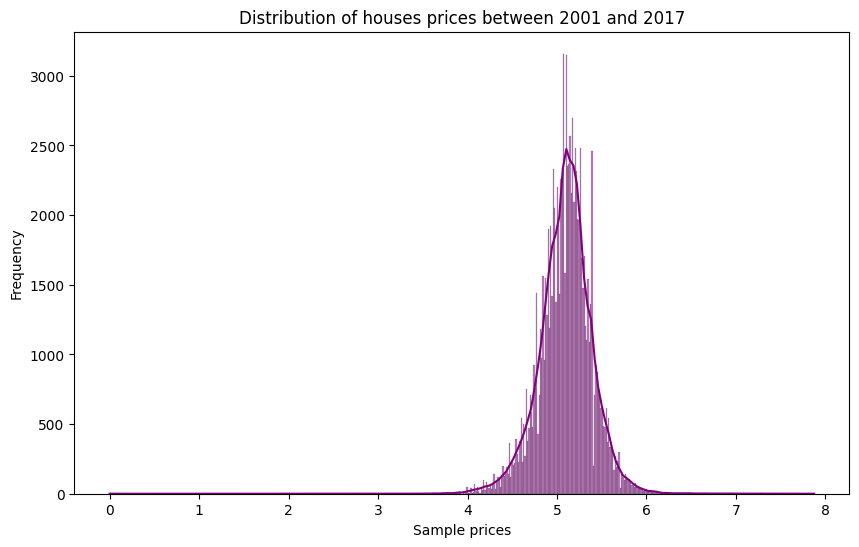

In [330]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data_new, x='Price_log', kde = True,color='purple')
plt.title('Distribution of houses prices between 2001 and 2017')
plt.xlabel('Sample prices')
plt.ylabel('Frequency')
plt.show()

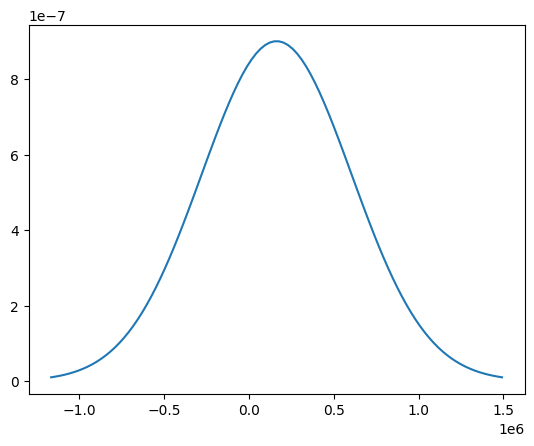

442859.1748739371

In [331]:
min_val = data_new['Price'].describe()['min']
mean_val = data_new['Price'].describe()['mean']
std_val = data_new['Price'].describe()['std']
max_val = data_new['Price'].describe()['max']
Q3 = data_new['Price'].describe()['25%']
Q1 = data_new['Price'].describe()['75%']
x = np.linspace(mean_val - 3*std_val, mean_val + 3*std_val, 100)
from scipy.stats import norm 
norm.pdf(x, mean_val, std_val)
plt.plot(x, norm.pdf(x, mean_val, std_val)) 
plt.show() 
std_val

<Axes: >

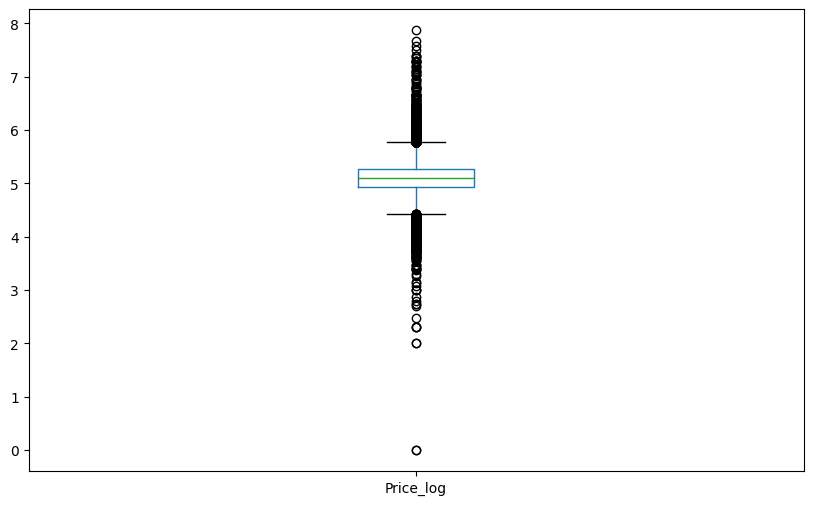

In [332]:
data_new.boxplot(column =['Price_log'], figsize= (10, 6), grid=False)

In [333]:
data_new['year'].describe()

count    102808.000000
mean       2007.885447
std           4.952905
min        2001.000000
25%        2004.000000
50%        2007.000000
75%        2013.000000
max        2017.000000
Name: year, dtype: float64

In [334]:
filter = (data_new['Price'] >= 1) & (data_new['Price'] < max_val)
data_new = data_new.loc[filter, :]
data_new.describe()


,Price,date,month,year,old_new_codes,property_types_codes,duration_code,Price_log
count,1.028070e+05,102807,102807.000000,102807.000000,102807.000000,102807.000000,102807.000000,102807.000000
mean,1.626595e+05,2008-05-28 01:15:38.212378624,6.729775,2007.885368,0.110489,2.371424,0.110489,5.096991
min,1.000000e+00,2001-01-01 00:00:00,1.000000,2001.000000,0.000000,0.000000,0.000000,0.000000
25%,8.500000e+04,2004-02-20 00:00:00,4.000000,2004.000000,0.000000,1.000000,0.000000,4.929419
50%,1.280000e+05,2007-04-25 00:00:00,7.000000,2007.000000,0.000000,3.000000,0.000000,5.107210
75%,1.850000e+05,2013-02-21 00:00:00,10.000000,2013.000000,0.000000,4.000000,0.000000,5.267172
max,4.626754e+07,2017-06-28 00:00:00,12.000000,2017.000000,1.000000,4.000000,1.000000,7.665276
std,3.764844e+05,NaN,3.331452,4.952864,0.313499,1.494532,0.313499,0.296683


In [335]:
columns = ['Price', 'month', 'year', 'old_new_codes', 'property_types_codes',
       'duration_code']
data_new = data_new.loc[:, columns]
filter 
data_new.head()

,Price,month,year,old_new_codes,property_types_codes,duration_code
132800,112000,11,2001,1,3,1
132801,62500,7,2001,0,1,0
132802,72500,6,2001,0,4,0
132803,35000,4,2001,0,1,0
132804,113000,10,2001,0,1,0


In [336]:
 data_new.describe()

,Price,month,year,old_new_codes,property_types_codes,duration_code
count,1.028070e+05,102807.000000,102807.000000,102807.000000,102807.000000,102807.000000
mean,1.626595e+05,6.729775,2007.885368,0.110489,2.371424,0.110489
std,3.764844e+05,3.331452,4.952864,0.313499,1.494532,0.313499
min,1.000000e+00,1.000000,2001.000000,0.000000,0.000000,0.000000
25%,8.500000e+04,4.000000,2004.000000,0.000000,1.000000,0.000000
50%,1.280000e+05,7.000000,2007.000000,0.000000,3.000000,0.000000
75%,1.850000e+05,10.000000,2013.000000,0.000000,4.000000,0.000000
max,4.626754e+07,12.000000,2017.000000,1.000000,4.000000,1.000000


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

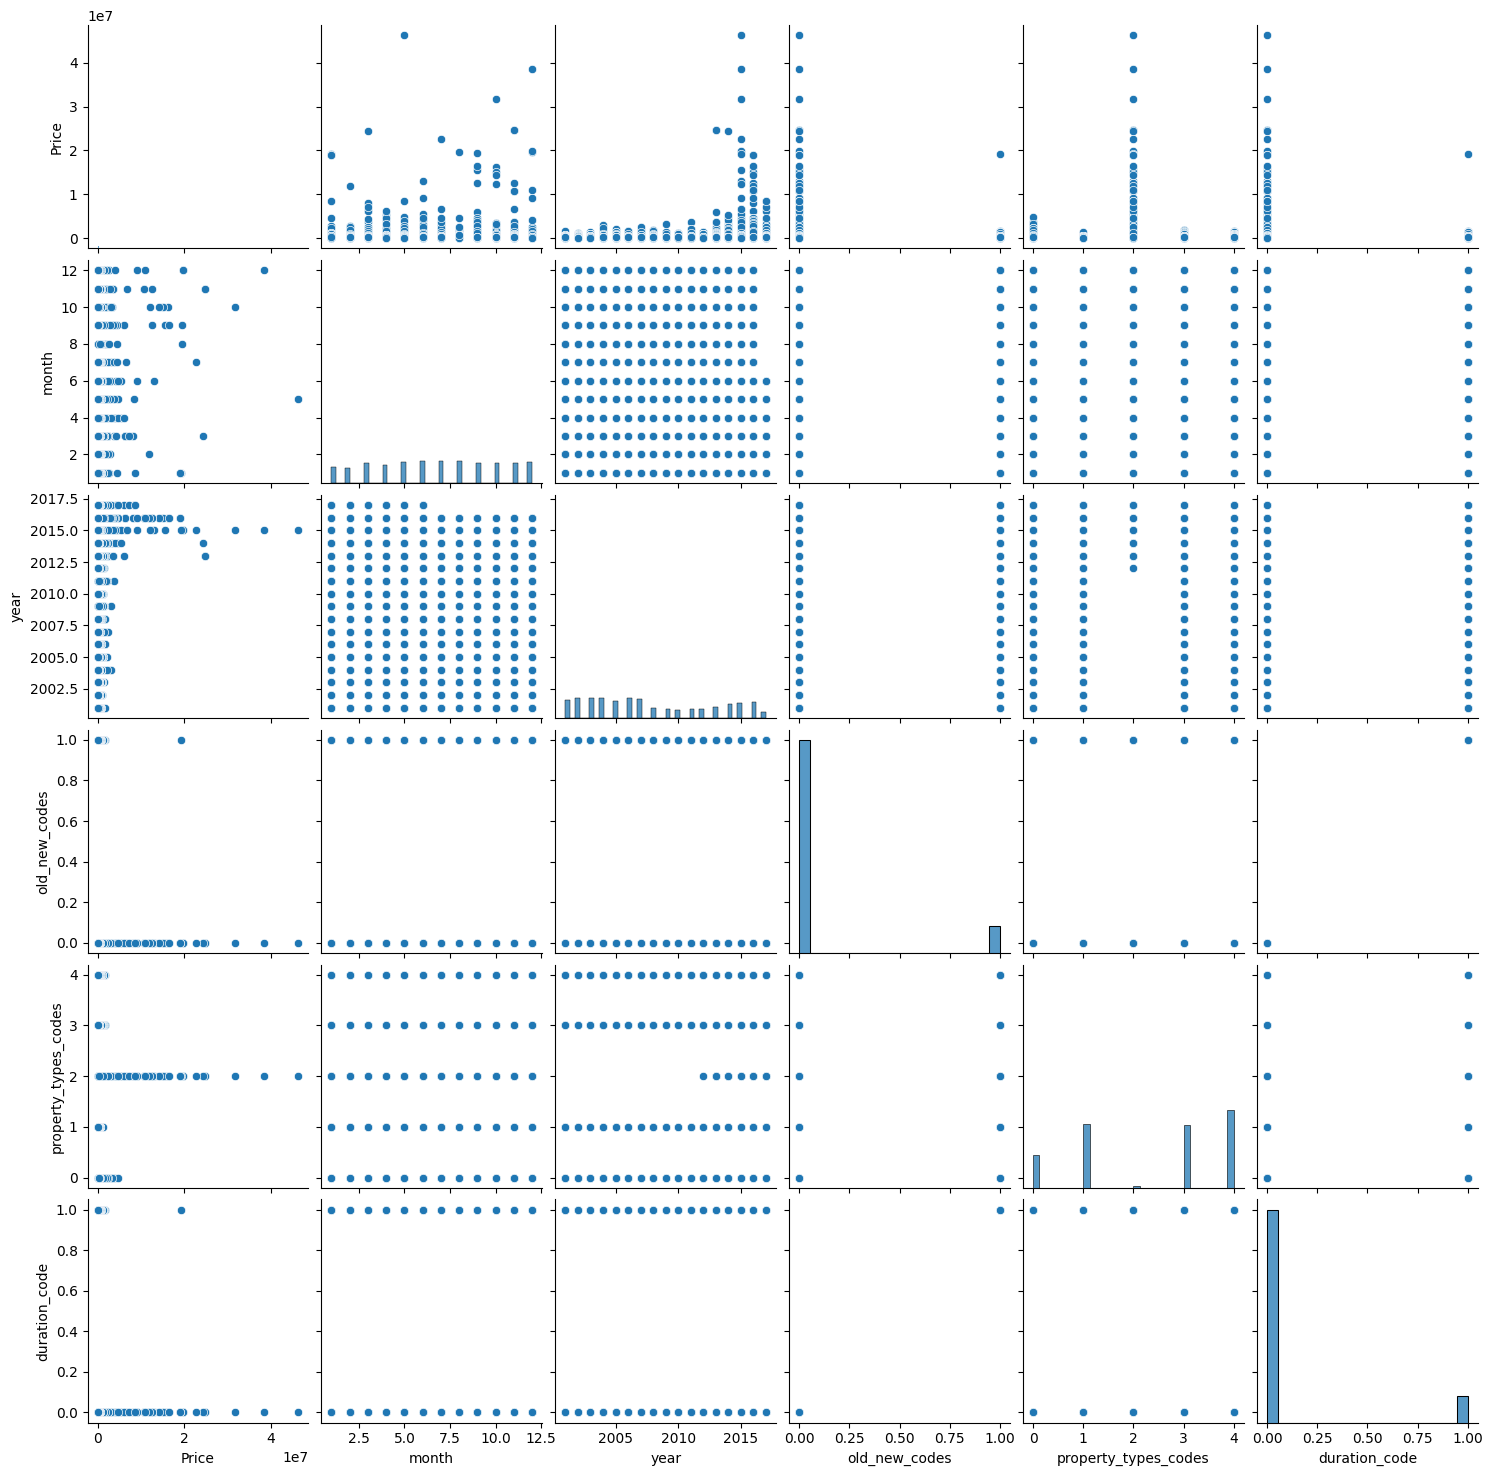

In [337]:
sns.pairplot(data_new)
plt.show()

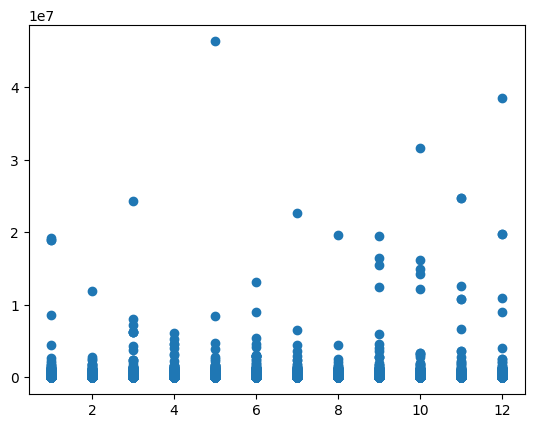

In [338]:
plt.scatter(data_new['month'], data_new['Price'])

In [339]:
est = smf.ols(formula='Price ~ month + year + property_types_codes + duration_code', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     410.9
Date:                Sun, 28 Jul 2024   Prob (F-statistic):               0.00
Time:                        15:29:10   Log-Likelihood:            -1.4650e+06
No. Observations:              102807   AIC:                         2.930e+06
Df Residuals:                  102802   BIC:                         2.930e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1.541e+07   4.73e+05    -32.566      0.000   -1.63e+07   -1.45e+07
month                 1588.8373    350.238      4.536      0.000     902.375    2275.300
year                  7772.4667    235.668     32.981      0.000    7310.560    8234.374
property_types_codes -1.774e+04    792.123    -22.398      0.000   -1.93e+04   -1.62e+04
duration_code         5547.1349   3782.371      1.467      0.142   -1866.263     1.3e+04
==============================================================================
Omnibus:                   346519.543   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     113981741804.934
Skew:                          60.971   Prob(JB):                         0.00
Kurtosis:                    5159.922   Cond. No.                     8.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [340]:
est = smf.ols(formula='Price ~ month', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     10.32
Date:                Sun, 28 Jul 2024   Prob (F-statistic):            0.00131
Time:                        15:29:10   Log-Likelihood:            -1.4658e+06
No. Observations:              102807   AIC:                         2.932e+06
Df Residuals:                  102805   BIC:                         2.932e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.55e+05   2646.544     58.582      0.000     1.5e+05     1.6e+05
month       1132.3372    352.439      3.213      0.001     441.560    1823.114
==============================================================================
Omnibus:                   344637.142   Durbin-Watson:                   1.900
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     108685197163.037
Skew:                          60.008   Prob(JB):                         0.00
Kurtosis:                    5038.657   Cond. No.                         17.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [341]:
slope, intercept, r, p, std_err = stats.linregress(data_new['month'],data_new['year'] )


print('slope          : ' , slope)
print('intercept      : ', intercept)
print('r              : ', r)
print('p-value.       : ', p)
print("standard error : ", std_err)

slope          :  -0.06401718361705189
intercept      :  2008.3161889831895
r              :  -0.043059968340976355
p-value.       :  2.1341967010983083e-43
standard error :  0.0046324713201987095


In [342]:
est = smf.ols(formula='Price ~ month + year + property_types_codes + duration_code', data=data_new).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     410.9
Date:                Sun, 28 Jul 2024   Prob (F-statistic):               0.00
Time:                        15:29:10   Log-Likelihood:            -1.4650e+06
No. Observations:              102807   AIC:                         2.930e+06
Df Residuals:                  102802   BIC:                         2.930e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1.541e+07   4.73e+05    -32.566      0.000   -1.63e+07   -1.45e+07
month                 1588.8373    350.238      4.536      0.000     902.375    2275.300
year                  7772.4667    235.668     32.981      0.000    7310.560    8234.374
property_types_codes -1.774e+04    792.123    -22.398      0.000   -1.93e+04   -1.62e+04
duration_code         5547.1349   3782.371      1.467      0.142   -1866.263     1.3e+04
==============================================================================
Omnibus:                   346519.543   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     113981741804.934
Skew:                          60.971   Prob(JB):                         0.00
Kurtosis:                    5159.922   Cond. No.                     8.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [343]:
from scipy import stats
slope, intercept, r, p, std_err = stats.linregress(data_new['month'],data_new['Price'])

In [344]:
X_new = pd.DataFrame({'month': [1,12, 8],
                      'year': [2002,2001,2016],
                      'property_types_codes': [1,1,1],
                      'duration_code': [1,0,0]
                      })
prediction_new = est.get_prediction(X_new)
10 ** prediction_new.predicted 

/tmp/ipykernel_33/3607849576.py:7: RuntimeWarning: overflow encountered in power
  10 ** prediction_new.predicted


array([inf, inf, inf])

In [345]:
prediction_new.conf_int()

array([[128390.88519618, 145765.29400513],
       [135474.44669993, 146996.95087479],
       [246314.73733919, 256619.96328111]])

In [346]:
prediction_new.summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,137078.089601,4432.276405,128390.885196,145765.294005,-595063.738716,869219.917918
1,141235.698787,2939.433735,135474.446700,146996.950875,-590877.257850,873348.655425
2,251467.350310,2628.901524,246314.737339,256619.963281,-480641.069715,983575.770335


In [347]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     410.9
Date:                Sun, 28 Jul 2024   Prob (F-statistic):               0.00
Time:                        15:29:10   Log-Likelihood:            -1.4650e+06
No. Observations:              102807   AIC:                         2.930e+06
Df Residuals:                  102802   BIC:                         2.930e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1.541e+07   4.73e+05    -32.566      0.000   -1.63e+07   -1.45e+07
month                 1588.8373    350.238      4.536      0.000     902.375    2275.300
year                  7772.4667    235.668     32.981      0.000    7310.560    8234.374
property_types_codes -1.774e+04    792.123    -22.398      0.000   -1.93e+04   -1.62e+04
duration_code         5547.1349   3782.371      1.467      0.142   -1866.263     1.3e+04
==============================================================================
Omnibus:                   346519.543   Durbin-Watson:                   1.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):     113981741804.934
Skew:                          60.971   Prob(JB):                         0.00
Kurtosis:                    5159.922   Cond. No.                     8.16e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.16e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Are people prepared paying 1,000,000 GDP for a property in Newcastle?

In [348]:

# Calculate mean and standard deviation
data = ([1.5e6])

# Calculate Z-scores
z_scores = abs((data - mean_val) / std_val)

# Print Z-scores
print("Z-Scores:", z_scores)
import scipy.stats

#find p-value
scipy.stats.norm.sf(abs(3.01)) * 2




Z-Scores: [3.018145]


0.002612476897538935

slope (B_1)     :  1.015754810120887
intercept (B_0) :  -223.69502064468816
r               :  0.8450481504423643
p-value.        :  9.762363961525708e-56
standard error  :  0.04567484386322979
PearsonRResult(statistic=0.8450481504423641, pvalue=9.762363961526279e-56)
SignificanceResult(statistic=0.8467935277668863, pvalue=3.485612274898771e-56)
SignificanceResult(statistic=0.6464275859642904, pvalue=4.54263771359339e-42)


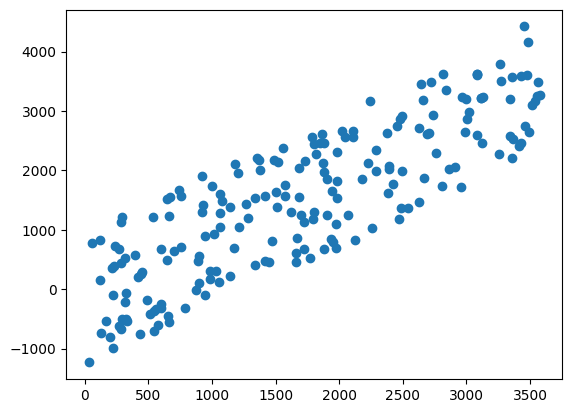

In [349]:
import matplotlib.pyplot as plt
from random import randint
xs = [randint(0, 3600) for x in range(0, 200)]
ys = [xs[i] + randint(-1300, 1000) for i in range(0, 200)]

from scipy import stats
slope, intercept, r, p, std_err = stats.linregress(xs, ys)

pred = [slope * xs[i] + intercept for i in range(0, 200)]


print('slope (B_1)     : ' , slope)
print('intercept (B_0) : ', intercept)
print('r               : ', r)
print('p-value.        : ', p)
print("standard error  : ", std_err)
print(scipy.stats.pearsonr(xs, ys))
print(scipy.stats.spearmanr(xs, ys))
print(scipy.stats.kendalltau(xs, ys))

plt.scatter(xs, ys)
#plt.plot(xs, pred, color = 'black')
plt.show()

In [350]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
df = pd.DataFrame({'xs' :xs, 'ys': ys})


model = smf.ols(formula='ys ~ xs', data=df).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ys   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     494.6
Date:                Sun, 28 Jul 2024   Prob (F-statistic):           9.76e-56
Time:                        15:29:11   Log-Likelihood:                -1583.8
No. Observations:                 200   AIC:                             3172.
Df Residuals:                     198   BIC:                             3178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -223.6950     91.318     -2.450      0.015    -403.777     -43.613
xs             1.0158      0.046     22.239      0.000       0.926       1.106
==============================================================================
Omnibus:                      117.226   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.850
Skew:                           0.028   Prob(JB):                      0.00162
Kurtosis:                       1.760   Cond. No.                     3.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [351]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
df = pd.DataFrame({'xs' :xs, 'ys': ys})


model = smf.ols(formula='ys ~ xs', data=df).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ys   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     494.6
Date:                Sun, 28 Jul 2024   Prob (F-statistic):           9.76e-56
Time:                        15:29:11   Log-Likelihood:                -1583.8
No. Observations:                 200   AIC:                             3172.
Df Residuals:                     198   BIC:                             3178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -223.6950     91.318     -2.450      0.015    -403.777     -43.613
xs             1.0158      0.046     22.239      0.000       0.926       1.106
==============================================================================
Omnibus:                      117.226   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.850
Skew:                           0.028   Prob(JB):                      0.00162
Kurtosis:                       1.760   Cond. No.                     3.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [352]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
df = pd.DataFrame({'xs' :xs, 'ys': ys})


model = smf.ols(formula='ys ~ xs', data=df).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ys   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     494.6
Date:                Sun, 28 Jul 2024   Prob (F-statistic):           9.76e-56
Time:                        15:29:11   Log-Likelihood:                -1583.8
No. Observations:                 200   AIC:                             3172.
Df Residuals:                     198   BIC:                             3178.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -223.6950     91.318     -2.450      0.015    -403.777     -43.613
xs             1.0158      0.046     22.239      0.000       0.926       1.106
==============================================================================
Omnibus:                      117.226   Durbin-Watson:                   1.891
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.850
Skew:                           0.028   Prob(JB):                      0.00162
Kurtosis:                       1.760   Cond. No.                     3.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

slope          :  0.04196875462866218
intercept      :  2562.934462355525
r              :  0.029289497739831367
p-value.       :  0.6805534053632534
standard error :  0.10178767574310374


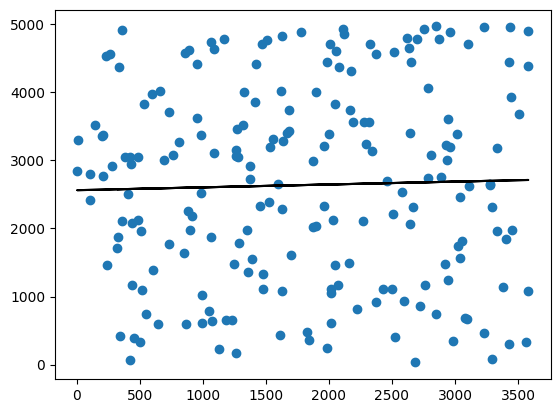

In [353]:
import matplotlib.pyplot as plt
from random import randint
xs = [randint(0, 3600) for x in range(0, 200)]
ys = [randint(0, 5000)  for i in range(0, 200)]

from scipy import stats
slope, intercept, r, p, std_err = stats.linregress(xs, ys)
pred = [slope * xs[i] + intercept for i in range(0, 200)]

print('slope          : ' , slope)
print('intercept      : ', intercept)
print('r              : ', r)
print('p-value.       : ', p)
print("standard error : ", std_err)
plt.scatter(xs, ys)
plt.plot(xs, pred, color = 'black')
plt.show()


In [354]:
print(scipy.stats.pearsonr(xs, ys))
print(scipy.stats.spearmanr(xs, ys))
print(scipy.stats.kendalltau(xs, ys))

PearsonRResult(statistic=0.029289497739831378, pvalue=0.6805534053632534)
SignificanceResult(statistic=0.03689731079768544, pvalue=0.6039610717660624)
SignificanceResult(statistic=0.028348831364664494, pvalue=0.5511729588332239)


In [355]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
df = pd.DataFrame({'xs' :xs, 'ys': ys})


model = smf.ols(formula='ys ~ xs', data=df).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ys   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1700
Date:                Sun, 28 Jul 2024   Prob (F-statistic):              0.681
Time:                        15:29:11   Log-Likelihood:                -1738.5
No. Observations:                 200   AIC:                             3481.
Df Residuals:                     198   BIC:                             3488.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2562.9345    208.739     12.278      0.000    2151.297    2974.571
xs             0.0420      0.102      0.412      0.681      -0.159       0.243
==============================================================================
Omnibus:                       71.129   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               11.167
Skew:                          -0.058   Prob(JB):                      0.00376
Kurtosis:                       1.848   Cond. No.                     4.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""